In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
# Data Manipulation and Analysis
import numpy as np
import pandas as pd
import os
from collections import Counter, defaultdict
import glob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
import cv2

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


In [12]:
# Define dataset paths and class names
dataset_path = '../Datasets/TrafficSignsSet/car'
class_names = [
    'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110',
    'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50',
    'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop'
]

print(f"Dataset path: {dataset_path}")
print(f"Number of classes: {len(class_names)}")
print("\nClass names:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Dataset path: ../Datasets/TrafficSignsSet/car
Number of classes: 15

Class names:
  0: Green Light
  1: Red Light
  2: Speed Limit 10
  3: Speed Limit 100
  4: Speed Limit 110
  5: Speed Limit 120
  6: Speed Limit 20
  7: Speed Limit 30
  8: Speed Limit 40
  9: Speed Limit 50
  10: Speed Limit 60
  11: Speed Limit 70
  12: Speed Limit 80
  13: Speed Limit 90
  14: Stop


In [3]:
def load_annotations(split_path):
    """Load all annotations from a dataset split."""
    annotations = []
    labels_path = os.path.join(split_path, 'labels')
    
    if not os.path.exists(labels_path):
        print(f"Labels path not found: {labels_path}")
        return annotations
    
    for label_file in glob.glob(os.path.join(labels_path, '*.txt')):
        image_name = os.path.basename(label_file).replace('.txt', '.jpg')
        
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    annotations.append({
                        'image_name': image_name,
                        'class_id': class_id,
                        'class_name': class_names[class_id],
                        'x_center': x_center,
                        'y_center': y_center,
                        'width': width,
                        'height': height,
                        'area': width * height
                    })
    
    return annotations

# Load annotations for all splits
train_annotations = load_annotations(os.path.join(dataset_path, 'train'))
valid_annotations = load_annotations(os.path.join(dataset_path, 'valid'))
test_annotations = load_annotations(os.path.join(dataset_path, 'test'))

print(f"Train annotations: {len(train_annotations)}")
print(f"Valid annotations: {len(valid_annotations)}")
print(f"Test annotations: {len(test_annotations)}")
print(f"Total annotations: {len(train_annotations) + len(valid_annotations) + len(test_annotations)}")


Train annotations: 4298
Valid annotations: 944
Test annotations: 770
Total annotations: 6012


## 1. Class Distribution Analysis

These plots show how many examples we have of each traffic sign type. This helps us understand:
- **Data balance**: Are some sign types much more common than others?
- **Training challenges**: Classes with few examples might be harder to learn
- **Augmentation needs**: Which classes might need more data


=== CLASS DISTRIBUTION ANALYSIS ===


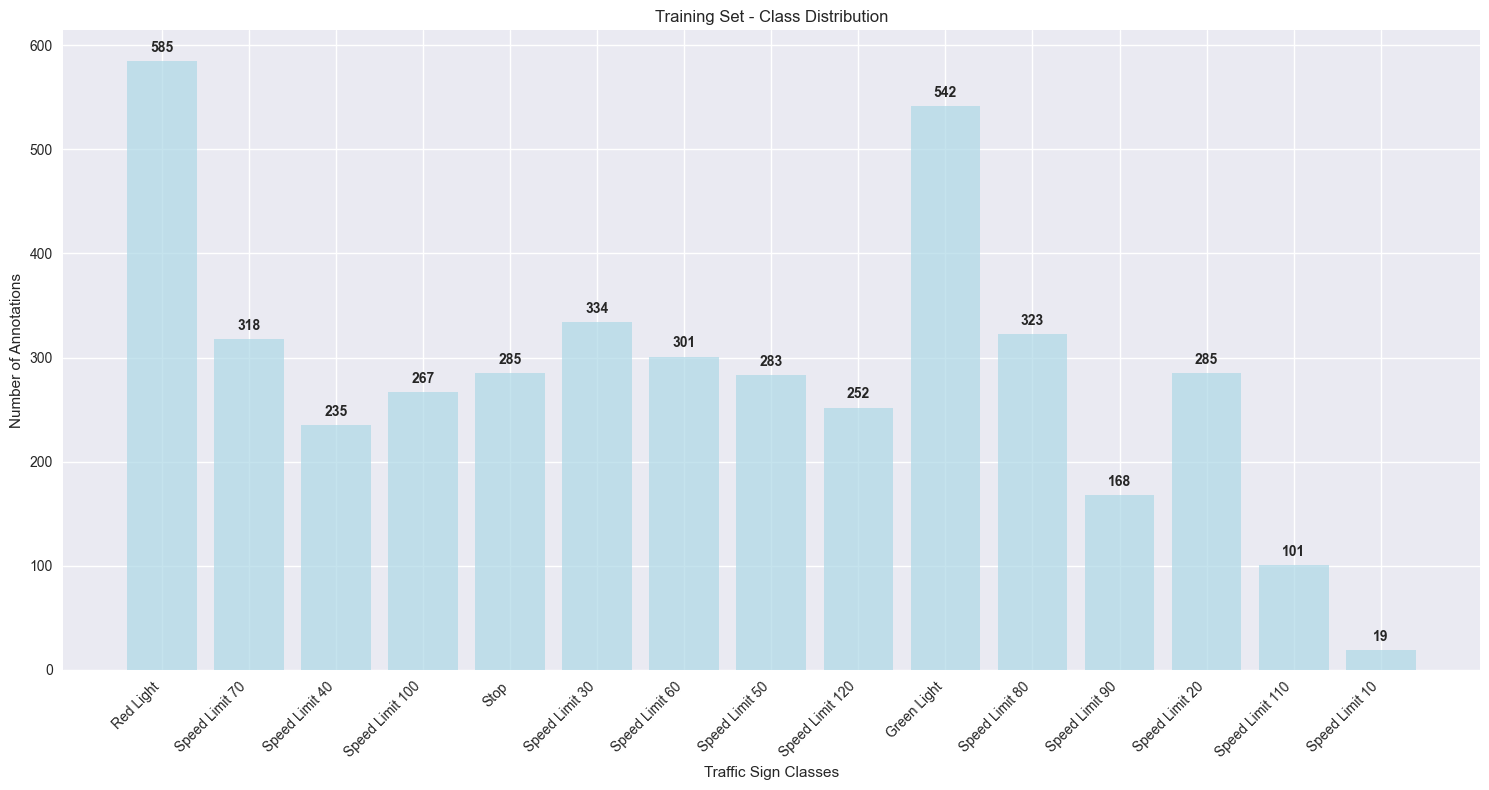

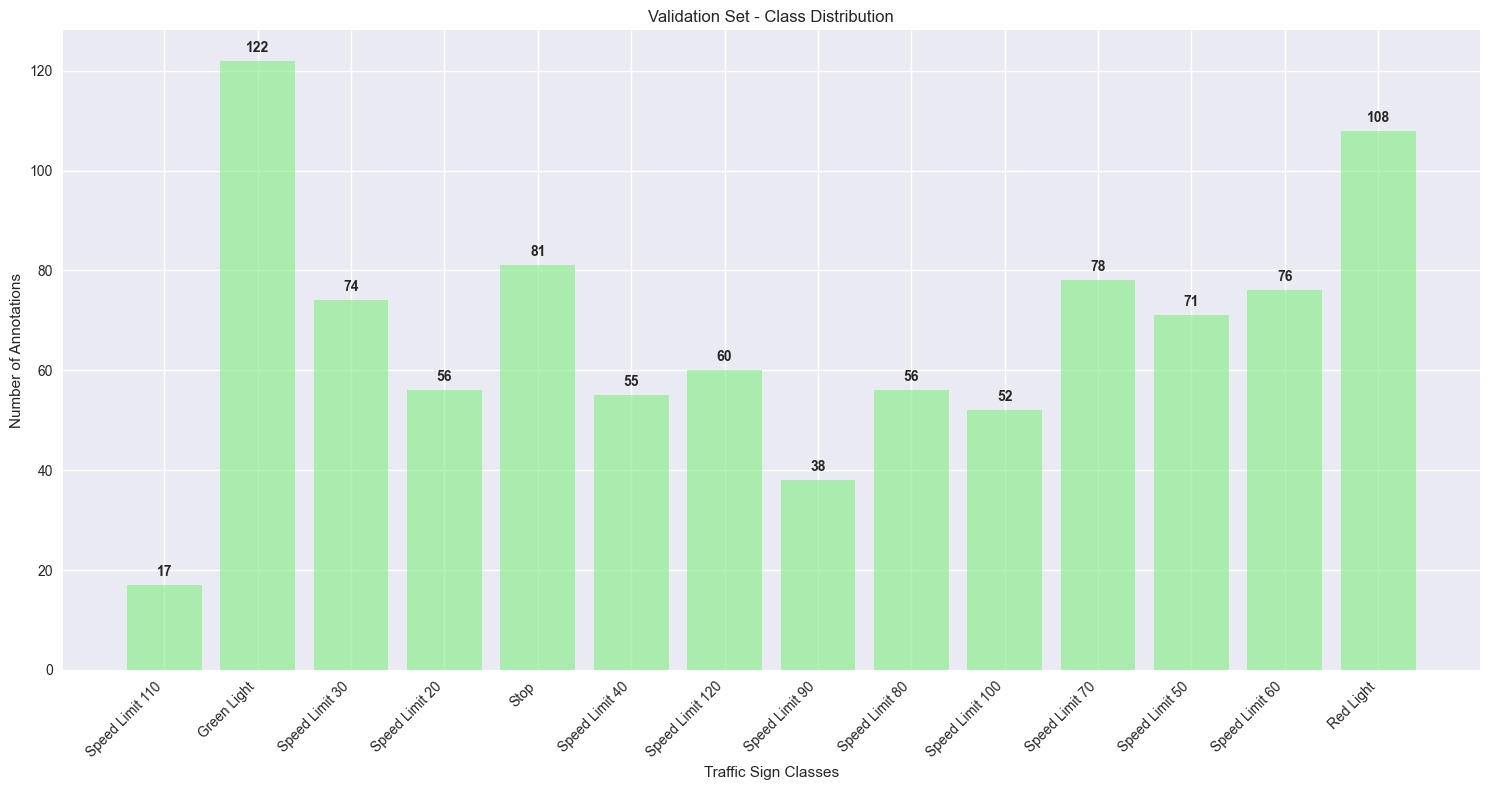

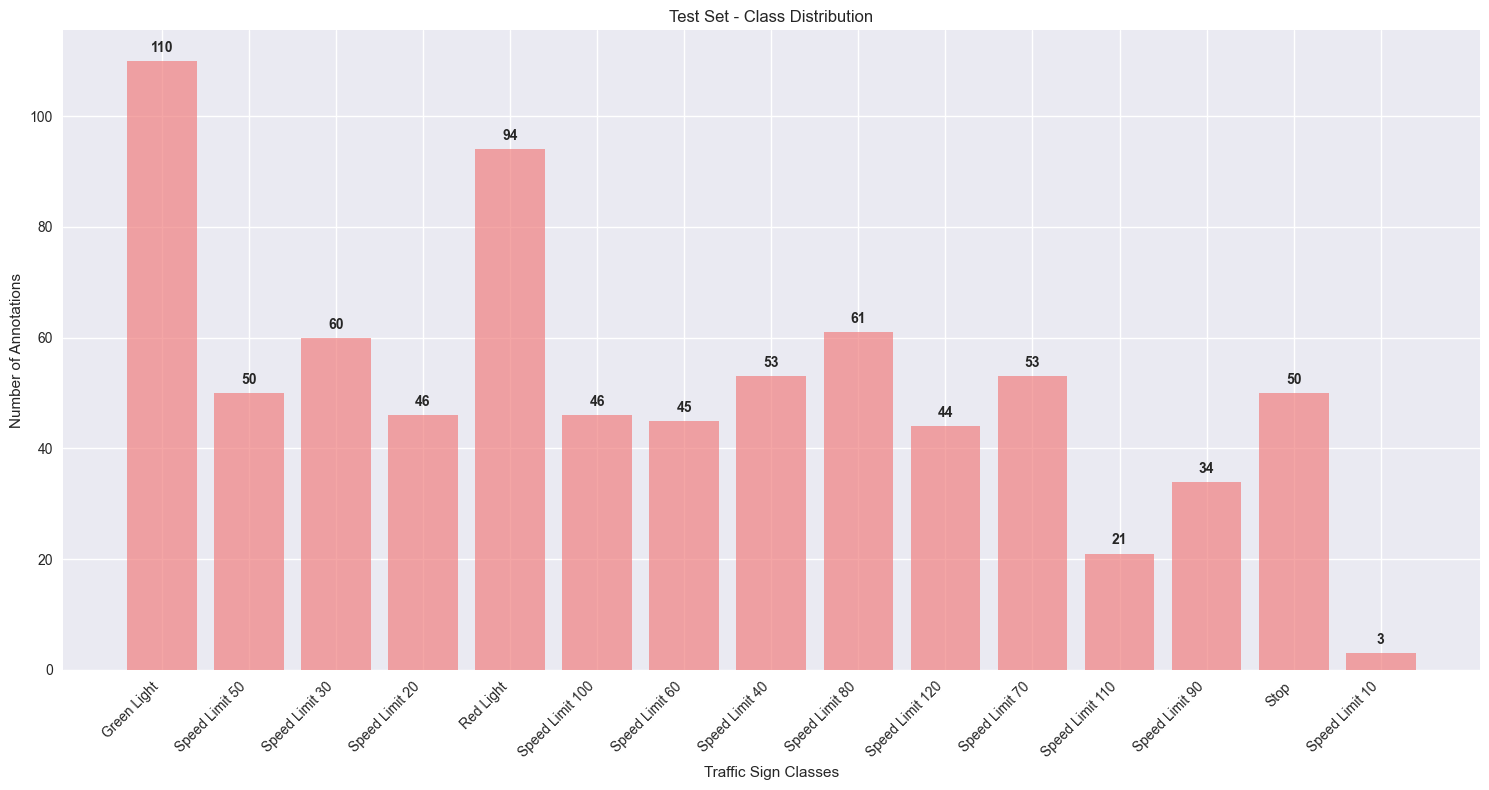

In [4]:
# 1. Class Distribution Analysis
def plot_class_distribution(annotations, title, color='skyblue'):
    """Plot class distribution for a dataset split."""
    class_counts = Counter([ann['class_name'] for ann in annotations])
    
    plt.figure(figsize=(15, 8))
    bars = plt.bar(range(len(class_counts)), list(class_counts.values()), color=color, alpha=0.7)
    plt.xlabel('Traffic Sign Classes')
    plt.ylabel('Number of Annotations')
    plt.title(f'{title} - Class Distribution')
    plt.xticks(range(len(class_counts)), list(class_counts.keys()), rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, count in zip(bars, class_counts.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(class_counts.values()), 
                str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

# Plot class distribution for each split
print("=== CLASS DISTRIBUTION ANALYSIS ===")
train_counts = plot_class_distribution(train_annotations, 'Training Set', 'lightblue')
valid_counts = plot_class_distribution(valid_annotations, 'Validation Set', 'lightgreen')
test_counts = plot_class_distribution(test_annotations, 'Test Set', 'lightcoral')


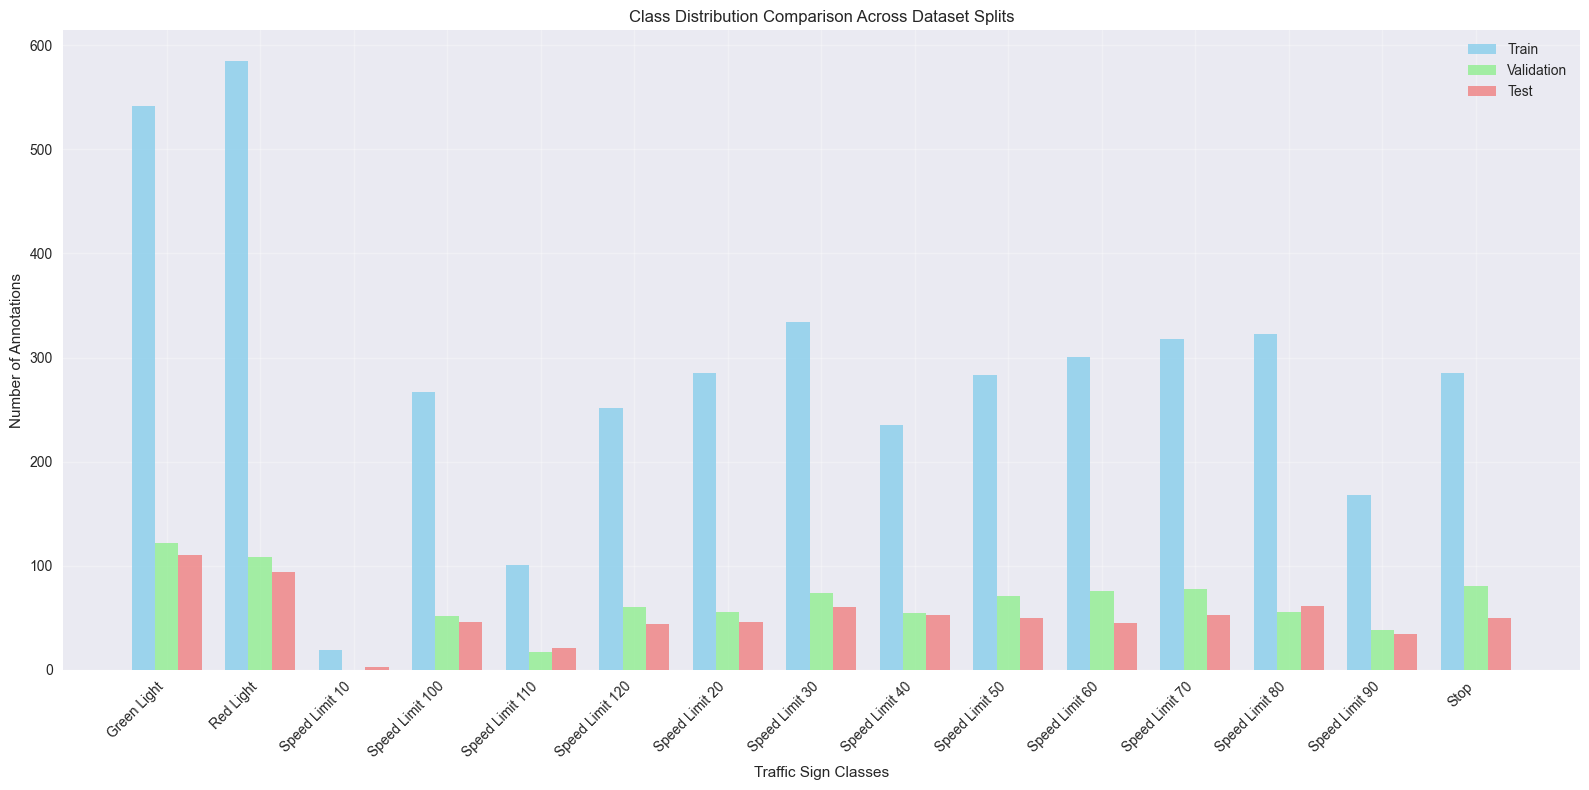

In [5]:
# 2. Compare class distribution across splits
def plot_split_comparison(train_counts, valid_counts, test_counts):
    """Compare class distribution across all splits."""
    all_classes = sorted(set(list(train_counts.keys()) + list(valid_counts.keys()) + list(test_counts.keys())))
    
    train_values = [train_counts.get(cls, 0) for cls in all_classes]
    valid_values = [valid_counts.get(cls, 0) for cls in all_classes]
    test_values = [test_counts.get(cls, 0) for cls in all_classes]
    
    x = np.arange(len(all_classes))
    width = 0.25
    
    plt.figure(figsize=(16, 8))
    plt.bar(x - width, train_values, width, label='Train', alpha=0.8, color='skyblue')
    plt.bar(x, valid_values, width, label='Validation', alpha=0.8, color='lightgreen')
    plt.bar(x + width, test_values, width, label='Test', alpha=0.8, color='lightcoral')
    
    plt.xlabel('Traffic Sign Classes')
    plt.ylabel('Number of Annotations')
    plt.title('Class Distribution Comparison Across Dataset Splits')
    plt.xticks(x, all_classes, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_split_comparison(train_counts, valid_counts, test_counts)


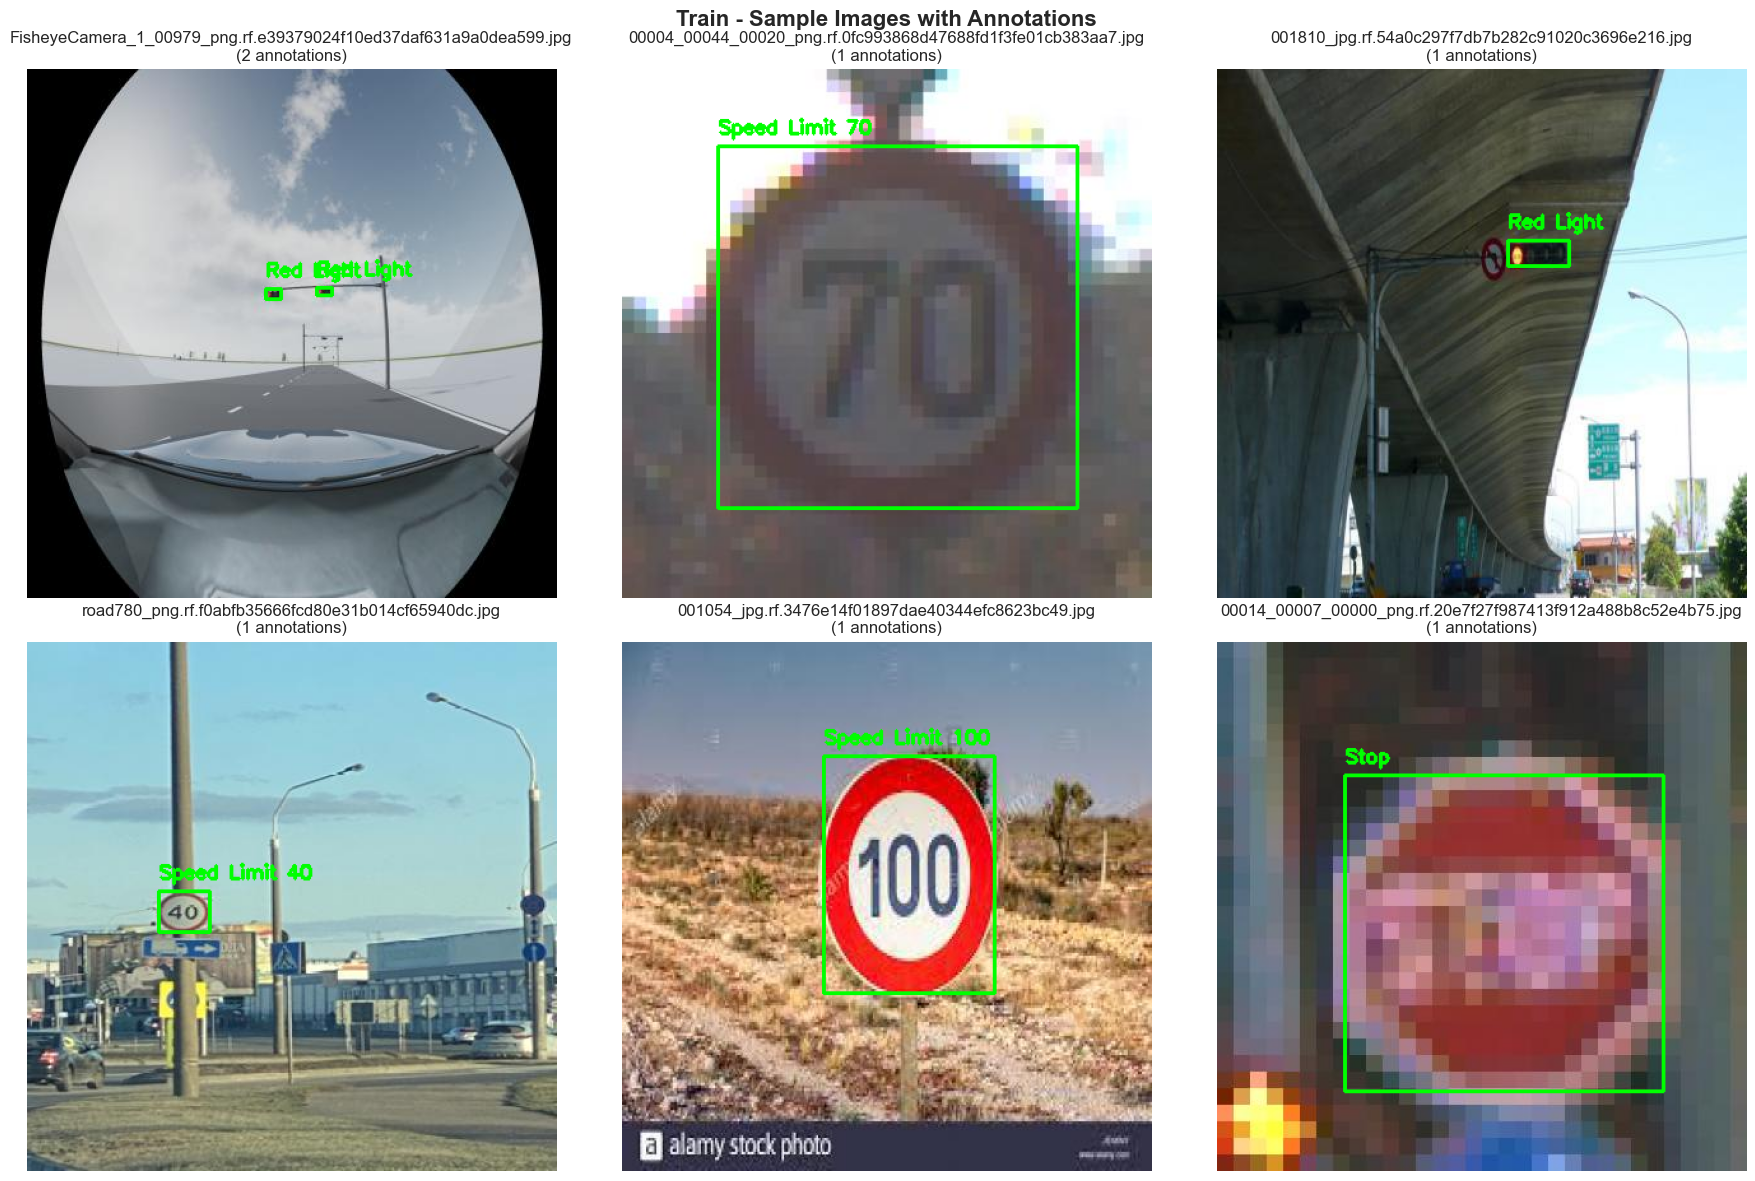

In [7]:
# 4. Sample Images with Annotations
def plot_sample_images(annotations, split_name, num_samples=6):
    """Display sample images with their annotations."""
    # Get unique images
    image_annotations = defaultdict(list)
    for ann in annotations:
        image_annotations[ann['image_name']].append(ann)
    
    # Select random samples
    sample_images = list(image_annotations.keys())[:num_samples]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'{split_name} - Sample Images with Annotations', fontsize=16, fontweight='bold')
    
    for idx, image_name in enumerate(sample_images):
        row = idx // 3
        col = idx % 3
        
        # Load image
        image_path = os.path.join(dataset_path, split_name.lower(), 'images', image_name)
        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Draw bounding boxes
            img_h, img_w = img.shape[:2]
            for ann in image_annotations[image_name]:
                x_center = int(ann['x_center'] * img_w)
                y_center = int(ann['y_center'] * img_h)
                width = int(ann['width'] * img_w)
                height = int(ann['height'] * img_h)
                
                x1 = x_center - width // 2
                y1 = y_center - height // 2
                x2 = x_center + width // 2
                y2 = y_center + height // 2
                
                # Draw rectangle
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Add label
                cv2.putText(img, ann['class_name'], (x1, y1-10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{image_name}\n({len(image_annotations[image_name])} annotations)')
            axes[row, col].axis('off')
        else:
            axes[row, col].text(0.5, 0.5, f'Image not found:\n{image_name}', 
                               ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].set_title('Image Not Found')
    
    plt.tight_layout()
    plt.show()

plot_sample_images(train_annotations, 'Train')


In [14]:
# 6. Summary Statistics
def print_summary_statistics():
    """Print comprehensive summary statistics."""
    print("=== DATASET SUMMARY STATISTICS ===")
    print(f"Dataset Path: {dataset_path}")
    print(f"Number of Classes: {len(class_names)}")
    print(f"Image Resolution: 416x416")
    print(f"Annotation Format: YOLO (class_id x_center y_center width height)")
    
    print(f"\n=== ANNOTATION COUNTS ===")
    print(f"Training Set: {len(train_annotations)} annotations")
    print(f"Validation Set: {len(valid_annotations)} annotations")
    print(f"Test Set: {len(test_annotations)} annotations")
    print(f"Total: {len(train_annotations) + len(valid_annotations) + len(test_annotations)} annotations")
    
    # Count unique images
    train_images = len(set([ann['image_name'] for ann in train_annotations]))
    valid_images = len(set([ann['image_name'] for ann in valid_annotations]))
    test_images = len(set([ann['image_name'] for ann in test_annotations]))
    
    print(f"\n=== UNIQUE IMAGES ===")
    print(f"Training Set: {train_images} images")
    print(f"Validation Set: {valid_images} images")
    print(f"Test Set: {test_images} images")
    print(f"Total: {train_images + valid_images + test_images} images")
    
    # Average annotations per image
    print(f"\n=== ANNOTATIONS PER IMAGE ===")
    if train_images > 0:
        print(f"Training Set: {len(train_annotations)/train_images:.2f} annotations/image")
    if valid_images > 0:
        print(f"Validation Set: {len(valid_annotations)/valid_images:.2f} annotations/image")
    if test_images > 0:
        print(f"Test Set: {len(test_annotations)/test_images:.2f} annotations/image")

print_summary_statistics()


=== DATASET SUMMARY STATISTICS ===
Dataset Path: ../Datasets/TrafficSignsSet/car
Number of Classes: 15
Image Resolution: 416x416
Annotation Format: YOLO (class_id x_center y_center width height)

=== ANNOTATION COUNTS ===
Training Set: 4298 annotations
Validation Set: 944 annotations
Test Set: 770 annotations
Total: 6012 annotations

=== UNIQUE IMAGES ===
Training Set: 3527 images
Validation Set: 801 images
Test Set: 637 images
Total: 4965 images

=== ANNOTATIONS PER IMAGE ===
Training Set: 1.22 annotations/image
Validation Set: 1.18 annotations/image
Test Set: 1.21 annotations/image
